# GPCP precipitation analysis (2010)

This notebook loads the GPCP monthly precipitation product for 2010, converts the longitude range from [-180, 180] to [0, 360], saves the result as a single NetCDF file, and produces a set of paper-relevant plots tied to the aerosol analysis (SSA, MAC, MEC, AOD) in the AeroCom project.

**Main variable:** `sat_gauge_precip` (mm/day), the combined satellite-gauge precipitation estimate.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os, sys, glob

# Robust project-root discovery (works whether the notebook is run from py/ or notebooks/)
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir) if os.path.basename(notebook_dir) in ('py', 'notebooks') else notebook_dir
py_dir = os.path.join(project_root, 'py')

if py_dir not in sys.path:
    sys.path.insert(0, py_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from functions import create_region_mask, regional_aggregate

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')

Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python dir:   /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py


## 1. Load GPCP monthly files and convert longitude to 0-360

In [2]:
# Load the 12 monthly GPCP files for 2010
prec_files = sorted(glob.glob(os.path.join(project_root, 'Data/Prec', 'GPCPMON_L3_2010*_V3.3.nc4')))
print(f'Found {len(prec_files)} GPCP files')

# Open as a single dataset along the time dimension
gpcp = xr.open_mfdataset(prec_files, combine='nested', concat_dim='time')
print(f'Original lon range: {float(gpcp.lon.min().values):.2f} to {float(gpcp.lon.max().values):.2f}')

# Convert longitude from -180/+180 to 0-360 and sort
gpcp['lon'] = (gpcp['lon'] + 360) % 360
gpcp = gpcp.sortby('lon')
gpcp = gpcp.sortby('time')
print(f'Converted lon range: {float(gpcp.lon.min().values):.2f} to {float(gpcp.lon.max().values):.2f}')

# Save the converted dataset for reuse by other notebooks/scripts
out_path = os.path.join(project_root, 'Data/Prec', 'GPCP_2010_0-360.nc')
if not os.path.exists(out_path):
    gpcp.to_netcdf(out_path)
    print(f'Saved converted dataset to {out_path}')
else:
    print(f'Converted dataset already exists at {out_path}')

print(f'File size: {os.path.getsize(out_path) / 1e6:.2f} MB')
print('\nDataset structure:')
print(gpcp)

Found 12 GPCP files
Original lon range: -179.75 to 179.75
Converted lon range: 0.25 to 359.75
Converted dataset already exists at /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/Prec/GPCP_2010_0-360.nc
File size: 93.36 MB

Dataset structure:
<xarray.Dataset> Size: 112MB
Dimensions:                        (time: 12, lat: 360, lon: 720, bnds: 2)
Coordinates:
  * time                           (time) datetime64[ns] 96B 2010-01-01 ... 2...
  * lat                            (lat) float32 1kB 89.75 89.25 ... -89.75
  * lon                            (lon) float32 3kB 0.25 0.75 ... 359.2 359.8
Dimensions without coordinates: bnds
Data variables:
    sat_gauge_precip               (time, lat, lon) float32 12MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    sat_gauge_random_error         (time, lat, lon) float32 12MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    sat_gauge_absolute_bias_error  (time, lat, lon) float32 12MB dask.array<chunksize=(1, 360, 720

## 2. Create regional masks and compute monthly means

In [3]:
# Main precipitation variable
pr = gpcp['sat_gauge_precip']

# Region definitions (from py/linear_ref.py, adapted to 0-360)
mask_registry = {}
create_region_mask(pr, 'global',     lon_range=(0, 360),   lat_range=(-90, 90),  mask_registry=mask_registry)
create_region_mask(pr, 'africa',     lon_range=(15, 37),   lat_range=(-15, 0),   mask_registry=mask_registry)
create_region_mask(pr, 'amazon',     lon_range=(287, 317), lat_range=(-17, -3),  mask_registry=mask_registry)
create_region_mask(pr, 'outflow_af', lon_range=(350, 8),   lat_range=(-15, 3),   mask_registry=mask_registry)

# Fire-season / analysis windows used in the paper
fire_season = {
    'global':     slice('2010-01-01', '2010-12-31'),
    'africa':     slice('2010-06-01', '2010-09-30'),
    'amazon':     slice('2010-07-01', '2010-10-31'),
    'outflow_af': slice('2010-06-01', '2010-09-30'),
}

# Compute area-weighted monthly means for each region
ts_dict = {}
for region, mask in mask_registry.items():
    ts = regional_aggregate(pr, mask, spatial='mean', time_slice=fire_season[region], return_time_series=True)
    ts_dict[region] = ts.to_series()
    print(f'{region:12s}: mean = {ts_dict[region].mean():.3f} mm/day')

global      : mean = 3.075 mm/day
africa      : mean = 1.105 mm/day
amazon      : mean = 1.896 mm/day
outflow_af  : mean = 0.354 mm/day


## 3. Global/annual mean precipitation map for 2010

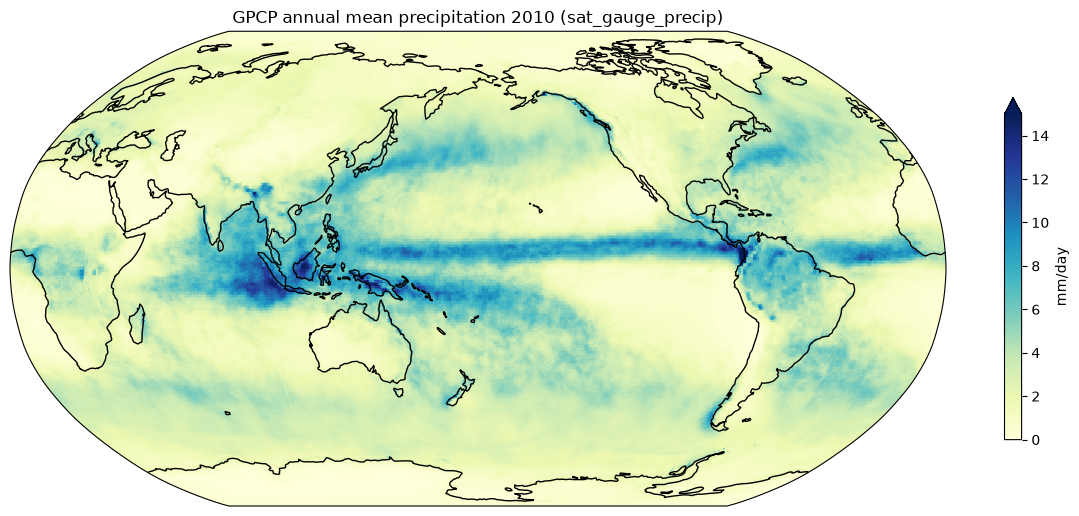

In [4]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)})
pr_mean = pr.mean(dim='time')
pr_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlGnBu',
             vmin=0, vmax=15, cbar_kwargs={'label': 'mm/day', 'shrink': 0.6})
ax.coastlines(resolution='110m')
ax.set_global()
ax.set_title('GPCP annual mean precipitation 2010 (sat_gauge_precip)')
plt.tight_layout()
fig.savefig(os.path.join(project_root, 'notebooks', 'GPCP_annual_mean_2010.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Monthly time series of global and tropical mean precipitation

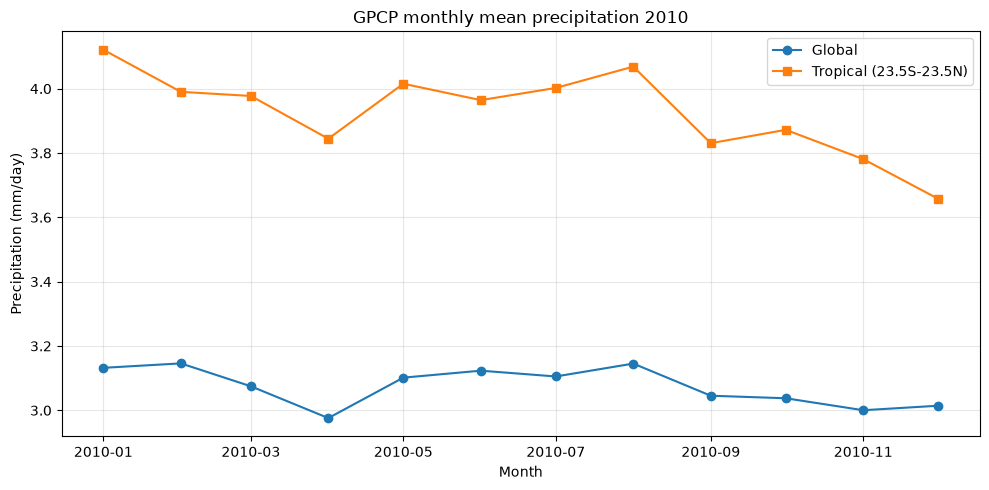

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts_dict['global'].index, ts_dict['global'].values, 'o-', label='Global', color='tab:blue')

# Tropical belt 23.5S-23.5N
trop_mask = create_region_mask(pr, 'tropical', lon_range=(0, 360), lat_range=(-23.5, 23.5))
ts_trop = regional_aggregate(pr, trop_mask, spatial='mean', time_slice=slice('2010-01-01', '2010-12-31'), return_time_series=True)
ax.plot(ts_trop.time.to_index(), ts_trop.values, 's-', label='Tropical (23.5S-23.5N)', color='tab:orange')

ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm/day)')
ax.set_title('GPCP monthly mean precipitation 2010')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(project_root, 'notebooks', 'GPCP_monthly_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Regional precipitation maps for the study regions

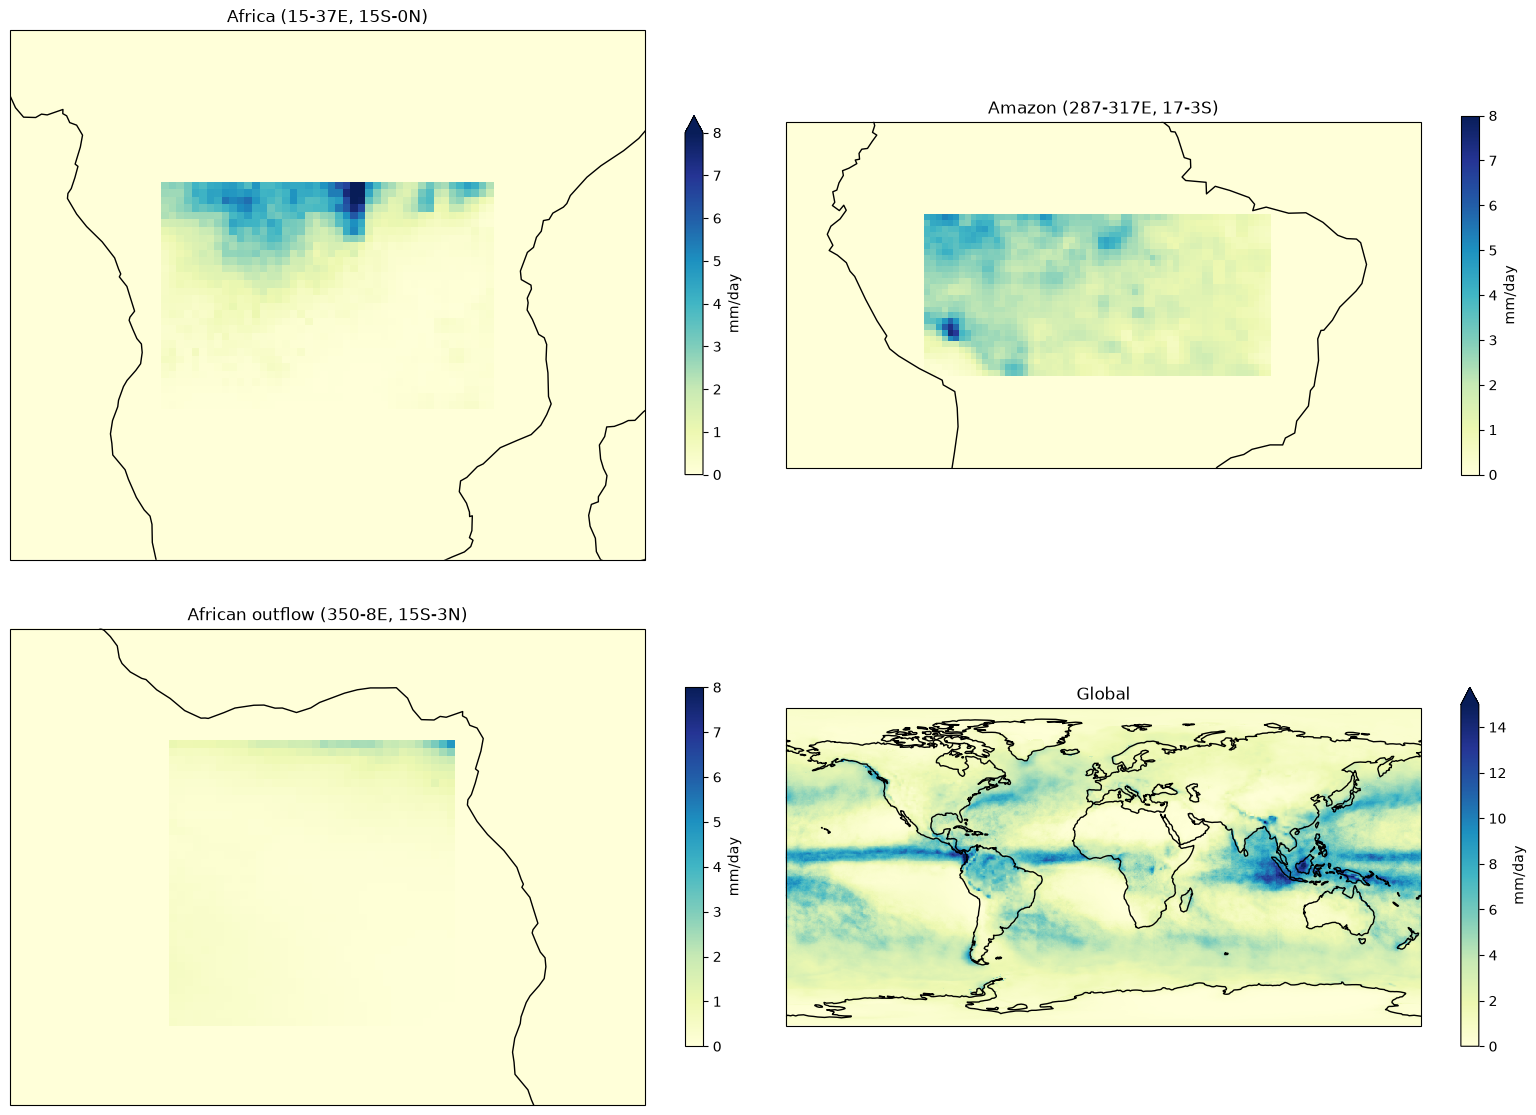

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
regions = ['africa', 'amazon', 'outflow_af', 'global']
titles = ['Africa (15-37E, 15S-0N)', 'Amazon (287-317E, 17-3S)', 'African outflow (350-8E, 15S-3N)', 'Global']
extents = {
    'africa': [5, 47, -25, 10],
    'amazon': [275, 330, -25, 5],
    'outflow_af': [340, 20, -20, 10],
    'global': None,
}

for ax, region, title in zip(axes.flat, regions, titles):
    mask = mask_registry[region]
    if region == 'global':
        field = pr_mean
        vmax = 15
    else:
        field = (pr * mask).sel(time=fire_season[region]).mean(dim='time')
        vmax = 8

    field.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlGnBu', vmin=0, vmax=vmax,
               cbar_kwargs={'label': 'mm/day', 'shrink': 0.6})
    ax.coastlines(resolution='110m')

    if extents[region] is not None:
        lon_w, lon_e, lat_s, lat_n = extents[region]
        # Cartopy expects monotonic longitudes; unwrap dateline-crossing windows.
        if lon_w > lon_e:
            lon_w -= 360
        ax.set_extent([lon_w, lon_e, lat_s, lat_n], crs=ccrs.PlateCarree())

    ax.set_title(title)

plt.tight_layout()
fig.savefig(os.path.join(project_root, 'notebooks', 'GPCP_regional_maps.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Monthly precipitation vs. collocated POLDER/model AOD

For the African fire season (June-September), we compare the GPCP monthly precipitation with collocated POLDER AOD_550 and one AeroCom model (ECHAM6-HAM2). The link to the aerosol analysis is that wet-season scavenging can suppress aerosol loading, so a negative correlation is often expected in strongly seasonal regions.

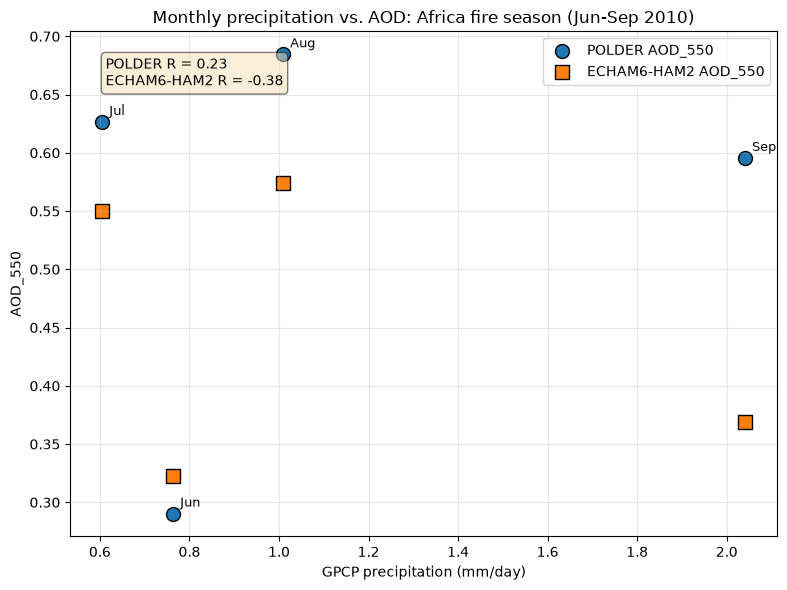

Monthly means:
     month  GPCP_precip_mm_day  POLDER_AOD_550  ECHAM6-HAM2_AOD_550
0  2010-06               0.764           0.290                0.322
1  2010-07               0.605           0.627                0.550
2  2010-08               1.009           0.685                0.574
3  2010-09               2.041           0.596                0.369


In [10]:
col_file = os.path.join(project_root, 'Data/AP3_POLDER_Collocated', 'POLDER_GRASP_coloc_3h_AP3_2010_v1.parquet')
region = 'africa'
mask = mask_registry[region]
lon_min, lon_max = mask.attrs['lon_range']
lat_min, lat_max = mask.attrs['lat_range']

# Read only the columns needed for this comparison
model_col = 'AOD_550_ECHAM6-HAM2_AP3-CTRL2016-PD'
cols = ['time', 'longitude', 'latitude', 'AOD_550', model_col]
df = pd.read_parquet(col_file, columns=cols)
df['month'] = df['time'].dt.to_period('M')

# Spatial subset for the selected region (supports dateline-wrapping longitudes)
if lon_min <= lon_max:
    mask_lon = (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
else:
    mask_lon = (df['longitude'] >= lon_min) | (df['longitude'] <= lon_max)
mask_lat = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)
df_reg = df[mask_lon & mask_lat].copy()

# Monthly means (fire season only)
months = [pd.Period('2010-06'), pd.Period('2010-07'), pd.Period('2010-08'), pd.Period('2010-09')]
precip_vals = []
aod_polder = []
aod_model = []
for m in months:
    p = ts_dict[region].loc[ts_dict[region].index.to_period('M') == m]
    precip_vals.append(float(p.iloc[0]) if len(p) > 0 else np.nan)
    aod_polder.append(float(df_reg[df_reg['month'] == m]['AOD_550'].mean()))
    aod_model.append(float(df_reg[df_reg['month'] == m][model_col].mean()))

precip_vals = np.array(precip_vals)
aod_polder = np.array(aod_polder)
aod_model = np.array(aod_model)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(precip_vals, aod_polder, s=100, color='tab:blue', edgecolor='k', label='POLDER AOD_550')
ax.scatter(precip_vals, aod_model, s=100, color='tab:orange', edgecolor='k', marker='s', label='ECHAM6-HAM2 AOD_550')
for i, month in enumerate(months):
    ax.annotate(month.strftime('%b'), (precip_vals[i], aod_polder[i]), textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('GPCP precipitation (mm/day)')
ax.set_ylabel('AOD_550')
ax.set_title('Monthly precipitation vs. AOD: Africa fire season (Jun-Sep 2010)')
ax.legend()
ax.grid(True, alpha=0.3)

# Correlations (n=4, fire season only; interpret with caution)
valid_p = ~np.isnan(precip_vals) & ~np.isnan(aod_polder)
valid_m = ~np.isnan(precip_vals) & ~np.isnan(aod_model)
if np.sum(valid_p) > 2:
    r_p = np.corrcoef(precip_vals[valid_p], aod_polder[valid_p])[0, 1]
    r_m = np.corrcoef(precip_vals[valid_m], aod_model[valid_m])[0, 1]
    ax.text(0.05, 0.95, f'POLDER R = {r_p:.2f}\nECHAM6-HAM2 R = {r_m:.2f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
fig.savefig(os.path.join(project_root, 'notebooks', 'GPCP_precip_vs_AOD_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Monthly means:')
print(pd.DataFrame({
    'month': [m.strftime('%Y-%m') for m in months],
    'GPCP_precip_mm_day': precip_vals,
    'POLDER_AOD_550': aod_polder,
    'ECHAM6-HAM2_AOD_550': aod_model,
}).round(3))

## 7. Summary and caveats

**Converted NetCDF file:** `Data/Prec/GPCP_2010_0-360.nc` contains the full 2010 GPCP monthly dataset with longitude converted from [-180, 180] to [0, 360] and sorted ascending. The main variable is `sat_gauge_precip` (mm/day).

**Plots produced:**
1. Global/annual mean precipitation map for 2010.
2. Monthly time series of global and tropical mean precipitation.
3. Regional maps for Africa, Amazon, African outflow, and the global domain.
4. Monthly scatter of precipitation vs. POLDER/model AOD for the African fire season.

**Caveats:**
- GPCP is a monthly product; any comparison with 3-hourly POLDER/model AOD uses monthly aggregation.
- The regional masks are box masks on the GPCP 0.5 grid; coastlines and topography are not resolved.
- The African outflow region wraps around 0 longitude; the map extent is shown with a central longitude that crosses the dateline.
- Some model AOD columns in the collocation file are entirely NaN (e.g., CAM5_CTRL2016, IMPACT, MIROC-SPRINTARS, SPRINTARS-T213); the example above uses ECHAM6-HAM2, which has full coverage in this region.
- Precipitation is a proxy for wet deposition/scavenging, but the relationship with AOD is complex and region-dependent.